# Integration of Ordinary Differential Equations Part 1

This week we start discussing the integration of ordinary differential equations. Recall that ordinary differential equations (ODEs) are differential equations of a single independent variable and partial differential equations (PDEs) have multiple independent variables.  Much of the research done in astrophysics comes down to solving differential equations that are either ODEs or PDEs and there are many methods used in different contexts so we will spend several weeks on these topics.  We begin with ODEs, which are generally more straight-forward to solve. We will find that some methods for solvisng PDEs build on ODE algorithms.

**Note about this notebook**

This notebook might provide more frustration than previous notebooks.
```
conda activate py311
conda install numba
conda install cython
conda install multiprocess
```
Things that might be required if you are using your own computer 
* May need to install numba (`pip install numba` or conda install) -- should be easy
* May need to install Cython (`pip install cython` or conda install) -- make take some troubleshooting to work on Mac, Windows but easy on Linux
* You should not need to install `f2py` but you may have trouble interfacing with the Fortran compiler on Mac, Windows but easy on Linux
* The video animations may not work without troubleshooting, but these are not essential to working through the notebook
* Some of the output cells may be quite long if they generate lots of compiler warnings

## 1 Differential Equations Review

In mathematics, an ordinary differential equation (ODE) is a differential equation containing one or more functions of one independent variable and the derivatives of those functions.

Given F, a function of x, y, and derivatives of y. Then an equation of the form
$$
F ( x , y , y' , … , y^{ (n − 1) } ) = y^{ ( n )} ,
$$
where
$$
y^{(n)} \equiv \frac{d^n y}{dx^n},
$$
is called an explicit ordinary differential equation of order n.

More generally, an implicit ordinary differential equation of order n takes the form:
$$
F ( x , y , y', \dots ,   y^{( n )} ) = 0.
$$
In principle, it can be ${\bf F}(x,y,z,\dots,y',z',\dots,y^{(2)}...)=0$. As long as there is only one independent variable (in this case x), which means that if x is given, all other quantities are fixed.
 
If there are more than one independent variable, it is partial differential equation:
$$
\frac{\partial f(x,y)}{\partial x}+\frac{\partial f(x,y)}{\partial y}=0
$$
We will tackle partial differential equations (PDEs) in a couple weeks.

### Equation orders

First-order (the degree of the derivative on the left side, y on the right side can be any order):
$$
\frac{dy}{dt}=f(t,y)
$$
e.g.
$$
\frac{dy}{dt}=t^3 y^4+y^2+t
$$
is a first order equation.

Second order: (the first derivative on the right side can be any power)
$$
\frac{d^2y}{dt^2}+\lambda \frac{dy}{dt}=f\left(t,\frac{dy}{dt},y\right)
$$
e.g.
\begin{equation}
\frac{d^2y}{dt^2}+\lambda \frac{dy}{dt}= 5 t^3\left(\frac{dy}{dt}\right)^5+t^7 y
\end{equation}
is a second order equation. In this example, t is the independent variable and y is the dependent variable.

### Linear and Nonlinear equations

If only the first power of y and all $d^n y/dt^n$ appears, e.g.:
$$
\frac{dy}{dt}=g(t)^5 y(t)
$$
the equation is linear.  A nice feature of linear equations is that their solutions can be combined with any linear relations to construct new solutions. If $y_{1}(t)$ and $y_{2}(t)$ are two solutions, $\alpha y_{1}(t)+\beta y_{2}(t)$ is also the solution.

The following is a non-linear equation because $y(t)$ comes in at second power on the right hand side:
$$
\frac{dy}{dt}=\lambda y(t)-\lambda^2 y^2(t).
$$

### Initial and boundary conditions

A solution to a first-order differential equation contains one integration constant, a solution to a second-order ODE contains two constants, etc.  These constants are set either with an initial condition or boundary condition, leading to initial value and boundary value problems.

### Systems of ODEs

One can express ODEs of *any order* as N first-order ODEs with dependent variables: $\mathbf{y}=\{y^0,\dots,y^{N-1}\}$. The corresponding equations can be written as
\begin{eqnarray}
\frac{dy_0}{dt}&=&f_0(\mathbf{y}, t)\\
\frac{dy_1}{dt}&=&f_1(\mathbf{y}, t)\\
...\\
\frac{dy_{N-1}}{dt}&=&f_{N-1}(\mathbf{y}, t)
\end{eqnarray}
Which can be written in a concise vector form
$$
\frac{d\mathbf{y}(t)}{dt}=\mathbf{f}(\mathbf{y},t)
$$
where $\mathbf{f}(t)=(f_0, ..., f_{N-1})$ and functions on the right hand do not contain derivatives.

## 2 Solving ODEs Numerically

Most methods for solving ODEs involve taking steps in the independent variable and approximating the derivative(s) numerically as finite differences.  Higher order methods generally take multiple substeps, with different algorithms differing in the number of substeps taken and the finite difference expressions used.  Careful choices of these substeps can lead to higher accuracy, lower numerical cost, or preservation of some symmetry (conserved quantity).

### Euler's Method

$\newcommand{\vec}[1]{{\bf #1}}$
$\newcommand{\ee}{\end{eqnarray}}$

Consider the following general expression for a first ODE.
$$
\frac {d\vec{y}}{dt} = \vec{f}(\vec{y}, t),
$$
where $\vec{y}$ is a vector of variables, $t$ is the independent variable, and $\vec{f}()$ is some arbitrary vector function of $\vec{y}$ and $t$.  We can use a forward difference expression for the derivative to write 
$$
\frac {d\vec{y}}{dt} \approx \frac {\vec{y}_{n+1} - \vec{y}_n}{\Delta t} = \vec{f}(\vec{y}_n, t_n),\qquad (1)
$$
where $\Delta t = t_{n+1} - t_n$.  This is sometimes called the forward-Euler method.  This is not the only choice that could have been made, it is also possible to write it as
$$
\frac {\vec{y}_{n+1} - \vec{y}_n}{\Delta t} = \vec{f}(\vec{y}_{n+1}, t_{n+1}),\qquad (2)
$$
which is called the backward-Euler method. The derivative operator is the same in both cases, but the difference is the choice of either $t_{n}$ or $t_{n+1}$ on the right hand side.  Equation (2) gives rise to an **implicit** method. The method is called implict because $\vec{y}_{n+1}$ is not known at the start of the step, so this generally gives rise to matrix equations. Hence these can be expensive to solve (per step) and involve increase code complexity, but with the trade off that they can be more stable and allow for larger timesteps, making them ultimately faster. 

For now, we will focus on equation (1), which is called to **explicit** integration, since we only need $\vec{y}_{n}$, which is known at the beginning of the step. If we know the value at $\vec{y}(t_n)$, we can solve for $\vec{y}(t_{n+1})$ to be
$$
\vec{y}_{n+1} = \vec{y}_n + \vec{f}(\vec{y}_n, t_n)\Delta t.\qquad (3)
$$
If we take $\vec{f}$ to be a scalar function of just $t$, then it just becomes an ordinary integral, similar to what we have solved previously.

Equation (3) gives the correct answer for $\Delta t \rightarrow 0$, but it should never be used as superior methods abound.  To see why Euler's method is not recommended, let consider the error that this algorithm introduces for finite $\Delta t$.  We do a Taylor expansion of the true solution, $\vec{y}(t)$:
$$
\vec{y}_{n+1} \approx \vec{y}_n + \frac{d\vec{y}}{d t}(t_n)\Delta t + \frac 1 2 \frac{d^2\vec{y}}{d t^2}(t_n)\Delta t^2 + \mathcal{O}(\Delta t^3)
$$
The first two terms constitute Euler's method, so for each time step, we will accumulate an error that is proportional to $\Delta t^2$.  Since the number of steps over an interval $T$ goes like $T/\Delta t$, then the total error scales like $\Delta t$.  For sufficiently small $\Delta t$, then the error is still reduced, but it comes at the cost of lots of steps.  Because of the scaling with error, Euler's method is known as a first-order method.  To get better results we want a better scaling of the error with $\Delta t$.

As an example, lets consider the equation 
$$
\frac {dy}{dt} = \cos(t).
$$
We can see that we can solve this analytically by noting
$$
y(t) = \int\cos(t) dt = \sin(t) + C,
$$
where $C$ is a constant.  Let see how we can do this numerically. First we define a function for the derivatives

In [2]:
import numpy as np

# implement the derivative above
def derivatives(t, y): 
    return np.cos(t)

Now you might wonder why we passed y in the derivatives function. We shall return to this shortly. Now let us define Euler method.  
$$
y(t+\Delta t) = y(t) + \frac{dy}{dt}\Delta t
$$

## **Student Completion**

Implement the Euler's method as using $dy/dt$ using `derivatives()`.

In [3]:
#implement the euler's method as using dy/dt as
# defined by derivatives function above
def euler(derivatives, t, delta_t, y): 
    pass

In [4]:
# Mine
def euler(derivatives, t, delta_t, y): 
    return y + derivatives(t, y) * delta_t

Note that the euler function above follows the exact definition of euler's method as defined above.  Now lets drive this between $t=0$ and $t=100$

In [5]:
def run_euler(N=1000, t0=0, t1=100) :
    delta_t = (t1-t0)/N
    y = 0

    t_array = np.arange(t0,t1+delta_t,delta_t)
    y_array = np.zeros(t_array.size)

    y_array[0] = y
    for i in range(t_array.size-1):
        y_array[i+1] = euler(derivatives, t_array[i], delta_t, y_array[i])
    return t_array, y_array

Great.  Now lets plot this

Average Error:  0.050205318634947635


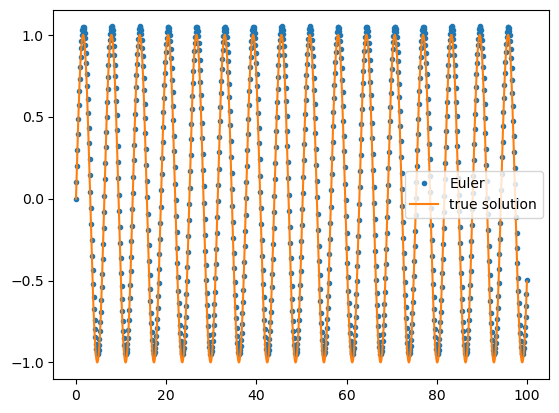

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

t_array, y_array = run_euler(N=1000)
plt.plot(t_array, y_array, '.', label='Euler')
plt.plot(t_array, np.sin(t_array), label='true solution')
plt.legend();

print("Average Error: ",np.average(abs(y_array-np.sin(t_array))))

Euler's method does ok, but we don't quite get the right values near the peaks and troughs and we needed 1000 points.  Try reducing it to $N=100$ and see how it performs.

### Runge-Kutta 2 step (RK2)

Euler's method is simple, but not that accurate.  There are much better methods  that are much more accurate and have other nice properties.  There is a slightly more complicated method that can give much better answers.

Runge-Kutta methods are an example of predictor-corrector methods.  Such methods "predicts" the value at $\vec{y}_{n+1}$ from the current solution at $\vec{y}_n$.  Then, using this predicted value, it performs a "corrector" step to increase the accuracy of the solution.  The generic two-step Runge-Kutta method is as follows:
$$
\vec{k}_1 = \vec{f}(\vec{y}_n, t_n) \Delta t 
$$
$$
\vec{k}_2 =  \vec{f}(\vec{y}_n + \beta \vec{k}_1, t_n + \alpha \Delta t) \Delta t
$$
$$
\vec{y}_{n+1} = \vec{y}_n + a \vec{k}_1 + b \vec{k}_2
$$
where $\vec{k}_1$ is the "predictor" subset, which is the same as an Euler step, and $\vec{k}_2$ is the "corrector" substep, and the total step ($n \rightarrow n+1$) is some linear combination of the two.  The constants, $\alpha$, $\beta$, $a$, and $b$ are chosen to make the entire algoritm accurate to $\mathcal{O}(\Delta t^3)$.  To determine these unknown constants, let perform a Taylor expansion of $\vec{y}_{n+1}$
$$
\vec{y}_{n+1} = \vec{y}_n + \frac{d\vec{y}}{d t}(t_n)\Delta t + \frac 1 2 \frac{d^2\vec{y}}{dt^2}(t_n)\Delta t^2
$$
Now 
$$
\frac{d^2\vec{y}}{dt^2}(t_n) = \frac {d\vec{f}(\vec{y},t)}{dt} = \frac {\partial \vec{f}(\vec{y},t)}{\partial t} + \frac{d\vec{y}}{dt}\cdot\vec{\nabla}_{\vec{y}}\vec{f} 
$$
$$
= \frac {\partial \vec{f}(\vec{y},t)}{\partial t} + \vec{f}\cdot\vec{\nabla}_{\vec{y}}\vec{f}
$$  
Thus we have 
$$
\vec{y}_{n+1} = \vec{y}_n + \vec{f}(\vec{y}_n, t_n)\Delta t + \frac 1 2 \left(\frac {\partial \vec{f}(\vec{y}_n,t_n)}{\partial t} + \vec{f}(\vec{y}_n,t_n)\cdot\vec{\nabla}_{\vec{y}}\vec{f}(\vec{y}_n,t_n)\right)\Delta t^2 +\mathcal{O}(\Delta t^3)\qquad (4)
$$
Now we Taylor expand out $\vec{k}_2$ to find
$$
\vec{k}_2 = \Delta t \vec{f}(\vec{y}_n + \beta \vec{k}_1, t_n + \alpha \Delta t) 
$$
$$
= \Delta t\left( \vec{f}(\vec{y}_n, t_n) + \alpha\Delta t\frac {\partial \vec{f}(\vec{y}_n,t_n)}{\partial t} + \beta\Delta t \vec{f}\cdot\vec{\nabla}_{\vec{y}}\vec{f}(\vec{y}_n,t_n)\right)
$$
Putting this all together, we have 
$$
\vec{y}_{n+1} = \vec{y}_n + (a+b)\Delta t \vec{f}(\vec{y}_n, t_n) + b\Delta t^2\left(\alpha\frac {\partial \vec{f}(\vec{y}_n,t_n)}{\partial t} + \beta\vec{f}\cdot\vec{\nabla}_{\vec{y}}\vec{f}(\vec{y}_n,t_n) \right)+\mathcal{O}(\Delta t^3)\qquad (5)
$$
Comparing Equations (4) and (5), we get the following conditions:
$$
a+b = 1 \qquad b\alpha = \frac 1 2 \qquad b\beta = \frac 1 2,
$$
which provides 3 equation for 4 unknowns.  Hence, there exist a infinite number of second order schemes that are possible, e.g., error per step that goes likes $\Delta t^3$, so the total error over a fixed interval goes like $\Delta t^2$.  So choosing $\alpha$ as a parameter, we have 
$$
\beta = \alpha \qquad b = \frac 1 {2\alpha} \qquad a = 1 - \frac 1 {2\alpha}
$$
Therefore, a generic second order Runge-Kutta scheme is then
$$
\vec{k}_1 =  \vec{f}(\vec{y}_n, t_n)\Delta t
$$
$$
\vec{k}_2 =  \vec{f}(\vec{y}_n + \alpha \vec{k}_1, t_n + \alpha \Delta t) \Delta t
$$
$$
\vec{y}_{n+1} = \vec{y}_n + \left(1 - \frac 1 {2\alpha}\right) \vec{k}_1 + \frac {\vec{k}_2} {2\alpha} 
$$

A few famous examples are 
1. Midpoint method: $\alpha = 1/2$ Estimate the values of y at the midpoint and solve for the derivative at the midpoint.  Use this midpoint derivative to complete the integration.  Note that prefactor in front of $\vec{k}_1$ in this case is zero.
2. Heun's Method: $\alpha = 1$ Estimate the values of y at the endpoint and give equal weight to both starting and endpoints to compute the derivative.

## **Student Completion**

Implement RK2 using the midpoint method, keeping it general.

In [7]:
# implement rk2.  derivatives have the signature derivatives(t,y) as above
def rk2(derivatives, t, dt, y):
    pass

In [8]:
#MY SOLUTION -remove
def rk2(derivatives, t, dt, y):
    k1 = derivatives(t, y)*dt
    k2 = derivatives(t+dt/2, y+k1/2)*dt
    return y + k2

In [9]:
# code for running RK2
def run_rk2(N=1000, t0=0, t1=100):
    dt = (t1-t0)/N
    y = 0
    t_array = np.arange(t0,t1+dt,dt)
    y_array = np.zeros(t_array.size)

    y_array[0] = y
    for i in range(t_array.size-1):
        y_array[i+1] = rk2(derivatives, t_array[i], dt, y_array[i])
    return t_array, y_array

Average Error:  0.0002660048570152808


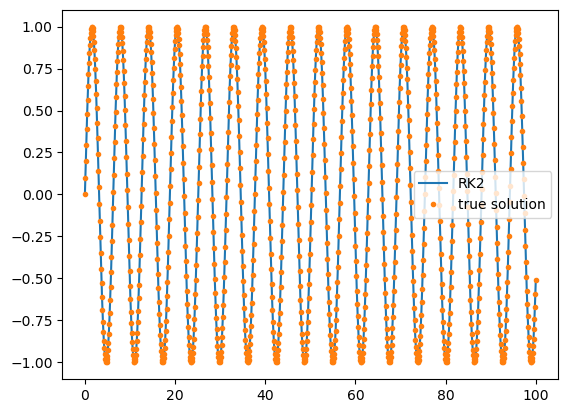

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

t_array, y_array = run_rk2(N=1000)
plt.plot(t_array, y_array, label='RK2')
plt.plot(t_array, np.sin(t_array),'.',label='true solution')
plt.legend();

print("Average Error: ",np.average(abs(y_array-np.sin(t_array))))

This is much more accurate than Eulers method for just a bit more computation. Try reducing it to $N=100$ and see how it performs. You should have a lower average error than Euler's method with $N=1000$ points.  This is the advantage of the higher order method!

### Higher Order Methods

Of course, a natural question to ask is can we got to higher than second order in $\Delta t$ and the answer is, of course, yes.  This require a larger number of substeps.  For example, one can construct a fourth order Runge-Kutta (RK4) method of the form

\begin{eqnarray}
 k_1 & = & f(y_n, t_n), \\
 k_2 & = & f\left(y_n + \Delta t \frac{k_1}{2}, t_n + \frac{\Delta t}{2}\right), \\
 k_3 & = & f\left(y_n + \Delta t \frac{k_2}{2}, t_n + \frac{\Delta t}{2}\right), \\
 k_4 & = & f\left(y_n + \Delta t k_3, t_n + \Delta t \right),
\end{eqnarray}
with
$$
y_{n+1} = y_n + \frac{\Delta t}{6}\left(k_1 + 2k_2 + 2k_3 + k_4 \right).
$$

We could, of course, code this up but it is useful to make use `scipy.integrate.ode()`, which provides a number of methods for higher order integration of ODEs.

Let use the same example as above with a fifth order Runge-Kutta integration.

Average Error:  2.983034564633468e-12


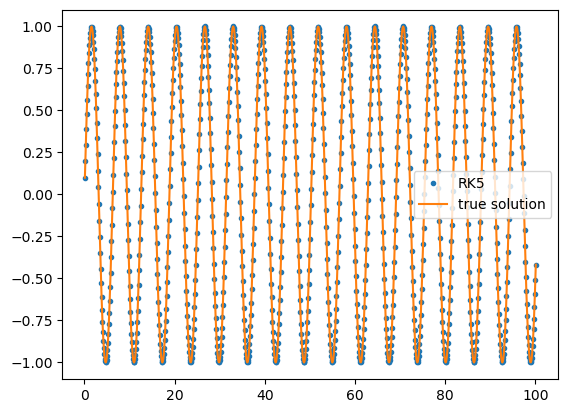

In [11]:
%matplotlib inline
import scipy.integrate as integrate

# set up RK5
integrator = integrate.ode(derivatives).set_integrator("dopri5")
N = 1000
#set up initial conditions
y0 = np.zeros(1)
t0 = 0
t1 = 100
dt = (t1-t0)/N
integrator.set_initial_value(y0, t0)

y_array = []
t_array = []
while integrator.successful() and integrator.t < t1 : 
    integrator.integrate(integrator.t+dt)
    t_array.append(integrator.t)
    y_array.append(integrator.y[0])
     
plt.plot(t_array, y_array, '.', label='RK5')
plt.plot(t_array, np.sin(t_array),label='true solution')
plt.legend();

print("Average Error: ",np.average(abs(y_array-np.sin(t_array))))

Again, we see that going to higher order results in a significant improvement in accuracy.

### Adaptive Timestepping

One thing that we have not discussed is the choice for $\Delta t$.  For an interval between $t_0$ and $t_1$, a larger $\Delta t$ results in fewer computational steps, which makes the calculation complete faster.  A smaller $\Delta t$, however, results in greater accuracy.

In principle, one can choose the timestep to vary to compromise between accuracy and computational expense. This is particularly important for functions where the right hand side of an ODE can take on large (positive or negative) values for a limited range of the dependent variable.  In these cases, it is useful to have a variable $\Delta t$ -- small when things change quickly and large when things change slowly.  

Suppose you have an ODE of the form
$$
\frac{d y}{d t} = f(y,t)
$$
Then according to Euler's method we have
$$
y_{n+1} - y_n = f(y_n,t_n)\Delta t
$$
Now suppose we want the change in $\Delta y = |y_{n+1} - y_n| < \alpha |y_n|$.  This means that
$$
\alpha |y_n| = |f(y_n,t_n)|\Delta t_{\rm max}
$$
This allows us to solve for $\Delta t_{\rm max}$ to be
$$
\Delta t_{\rm max} = \alpha \left|\frac{y_n}{f(y_n,t_n)}\right|
$$
Typically, you don't want $\alpha$ to be too large nor too small, but the optimal choice will often depend on the function being integrated.  It is useful to test values on a function with similar properties whose solution is known, but values between 0.01 and 0.1 often work well.  

At the same time, we don't want $\Delta t_{\rm max}$ to be so large that it totally misses an important change.  One can pick a $\Delta t_{\rm max,0} = (t_1 - t_0)/N_0$, where $N_0$ is a number between 10 or 100, but this may also depend on the function being integrated.

So a selection for $\Delta t$ at a time $t$ would be
$$
\Delta t = \min( t_1 - t, \min(\Delta t_{\rm max,0}, \Delta t_{\rm max}))
$$

Now lets try an example of this. Consider the ODE
$$
\frac{\partial y}{\partial t} = \frac 1 {\sigma} \exp\left(-\frac{t^2}{\sigma^2}\right)
$$
You probably recognize the answer to this one.  Integrated from $t=-\infty$ to $\infty$, it is $\sqrt{\pi}$.

## **Student Completion**

Give it a try yourself by implementing your own timestep.

In [12]:
# write a code to compute the timestep
def timestep(derivatives, t1, t, y, dt0, al=0.1):
    pass

In [13]:
# MY SOLUTION - REMOVE
def timestep(derivatives, t1, t, y, dt0, al=0.1):
    dydt = derivatives(t, y)
    if dydt == 0.:
        return min(t1-t, dt0)
    dt = al * abs(y/dydt)
    return min(t1-t, min(dt, dt0))

In [14]:
def gaussian(t, y, sigma=0.1):
    # prevent overflows that can happen for large exp(-t^2/sigma^2)
    if np.abs(t/sigma) > 10:
        return 0.
    return np.exp(-t**2/sigma**2)/sigma

def rk2(derivatives, t, dt, y):
    k1 = derivatives(t, y)*dt
    k2 = derivatives(t+dt/2, y+k1/2)*dt
    return y + k2

def run_gaussian(t0=-10, t1=10, N0 = 100): 
    y = 0
    t = t0
    dt0 = (t1 - t0)/N
    while t < t1 :
        dt = timestep(gaussian, t1, t, y, dt0)
        # use our RK2 implementation
        y = rk2(gaussian, t, dt, y)
        t += dt
        
    return y

print("RK2 with variable timestep: ",run_gaussian())
print("True solution: ",np.sqrt(np.pi))

RK2 with variable timestep:  1.7716536860195904
True solution:  1.7724538509055159


## Higher Order ODEs

Thus far we have discussed the case of first order odes (ODEs with first order derivatives). As alluded to above, it is straight-fowrad to extend the methods for first order ODEs to arbitrary high order ODEs.  The trick is to simply identify higher order derivatives as variables in themselves.  Consider the ODE
$$
\sum_{n=1}^{N}\frac{d^n f}{dx^n} = 0
$$
We can write this as a sum first order ODEs by the identification of 
$$
f_n = \frac{df_{n-1}}{dx} \qquad\textrm{and}\qquad f_0 = f
$$
Thus we have 
$$
\frac{df_{N-1}}{dx} + \sum_{n=1}^{N-1} f_n = 0,
$$
$$
\frac{df}{dx} = f_1
$$
$$
\frac{df_1}{dx} = f_2
$$
$$
\vdots
$$
$$
\frac{df_{N-2}}{dx} = f_{N-1}.
$$
So this converts a Nth order ODE to N first order ODEs, which we can solve.

As an example lets try a simple harmonic oscillator 
$$
\frac{d^2 x}{dt^2} = -x
$$
We of course know that the solution is 
$$
x(t) = A\cos(t+\phi)
$$

This is second order so we break this up into 2 first order equations
$$
\frac{dx}{dt} = v
$$
$$
\frac{dv}{dt} = -x
$$
Now lets implement this numerically.

In [15]:
# implement the SHO derivative as 2 first order equations
def SHO_derivatives(t, y):
    x = y[0]
    v = y[1]
    return np.array([v, -x])

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def rk2(derivatives, t, dt, y):
    k1 = derivatives(t, y)*dt
    k2 = derivatives(t+dt/2, y+k1/2)*dt
    return y + k2

# integrate from t0=0 to t
def run_SHO_rk2(t, delta_t) :
    y = np.zeros(2)
    y[0] = 1. # set initial condition
    t0 = 0.
    n = 0
    while t0 < t : 
        dt = min(t-t0 ,delta_t)
        # use our RK2 implementation
        y = rk2(SHO_derivatives, t0, dt, y)
        t0 += dt
        n += 1
        if n > 1000:
            break
    return y


y = run_SHO_rk2(2.*np.pi, 0.05)
print(y[0])

1.000094410607784


This seems to be working.  We can make an animation using matplotlib's `animation` module. I have tested this on the course server and it seems to be working. In the past I have had difficulties getting this to work in Jupyter notebooks on other machines, so **feel free to skip** if it becomes too much of a hassle.

In [17]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
from IPython import display 

fig, ax = plt.subplots()

def animate(i):
    ax.clear()
    delta_t = 0.05
    # Get the point from the points list at index i
    # Integration is done for each point -- not very efficient
    y = run_SHO_rk2(i*delta_t, delta_t)
    ax.plot(y[0], 0., color='green', marker='o')
    # Set the x and y axis to display a fixed range
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1,1])


ani = FuncAnimation(fig, animate, frames=250, interval=20, repeat=False)
video = ani.to_html5_video()
html = display.HTML(video)
display.display(html)
plt.close()

### Application: N-body Dynamics

The N-body problem is a classic problem in astronomy.  If two massive bodies (label i and j) interacting gravitationally, force of j on i is given by by
$$
\mathbf{F}_{i,j} = -\frac{G m_i m_j}{|\mathbf{r}_i - \mathbf{r}_j|^2} \hat{r},
$$
with
$$
\hat{r} = \frac{\mathbf{r}_i - \mathbf{r}_j}{|\mathbf{r}_i - \mathbf{r}_j|},
$$
and the force of i on j is given by $\mathbf{F}_{j,i} = - \mathbf{F}_{i,j}$.

When there are more than two particles, we can find the total force on i via
$$
\mathbf{F}_{i} = \sum_{i \ne j} \mathbf{F}_{i,j}
$$

For N particles, this is a system of 3N second order ODEs that we transform into 6N first order ODEs, and solve simultaneously via
$$
\mathbf{v}_i = \frac{d\mathbf{x}_i}{dt}
$$
and
$$
\mathbf{F}_i = m_i\frac{d\mathbf{v}_i}{dt}
$$
## **Student Completion**

Assume you have two bodies, implement the derivatives and run it.  It should look like two bodies orbiting each other with some translational motion. Since we are doing a numerical problem, we can choose code units with $G=1$, here. Such rescalings are common in numerical simulations.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

N_bodies = 2
M = np.array([1.0, 0.25])

def Nbody_derivatives(pos, vel):
# given N bodies, implement the force equations as stated above.
    dpdt = vel
    dvdt = np.zeros(vel.shape)
    for i in range(N_bodies) :
        for j in range(N_bodies) :
            if i == j : 
                continue
            r = np.linalg.norm( pos[j]-pos[i])
            ## add your code here
        
    return dpdt, dvdt

In [19]:
# MY SOLUTION -- Remove
N_bodies = 2
M = np.array([1.0, 0.25])

def Nbody_derivatives(pos, vel):
# given N bodies, implement the force equations as stated above.
    dpdt = vel
    dvdt = np.zeros(vel.shape)
    for i in range(N_bodies) :
        for j in range(N_bodies) :
            if i == j : 
                continue
            r = np.linalg.norm( pos[j]-pos[i])
            mass = M[j]
            rhat = (pos[i] - pos[j])/r
            dvdt[i] -= mass/(r*r)*rhat
        
    return dpdt, dvdt

In [20]:
# some simple initial conditions
def initial_conditions(): 
    pos_and_vel = np.zeros([N_bodies,6])

    pos_and_vel[0,0] = -1
    pos_and_vel[0,4] = -0.25
    pos_and_vel[1,0] = 1
    pos_and_vel[1,4] = 0.25
    return pos_and_vel

def run_Nbody_rk2(tend, tframe, dt):
    y = initial_conditions()
    p = y[:,0:3]
    v = y[:,3:6]
    t = 0
    tnext = tframe
    positions = []
    while t<tend :
        while t < tnext :
            # compute using rk2
            delta_t = min(tnext-t,dt)
            dpdt, dvdt = Nbody_derivatives(p, v) 
            phalf, vhalf = p+dpdt*0.5*delta_t, v+dvdt*0.5*delta_t
            dpdt, dvdt = Nbody_derivatives(phalf, vhalf)
            p, v = p + dpdt*delta_t, v + dvdt*delta_t
            t += delta_t
        positions.append(p.copy())
        tnext += tframe
    return positions

frames = 100
tframe = 0.25
dt = 0.025
positions = run_Nbody_rk2(frames*tframe, tframe, dt)

In [21]:
%matplotlib inline
fig, ax = plt.subplots(1, 1)

def animate(i, positions):
    ax.clear()
    # Get the point from the points list at index i
    pos = positions[i]
    ax.scatter(pos[0,0], pos[0,1], color='green', marker='o')
    ax.scatter(pos[1,0], pos[1,1], color='red', marker='o')
    # Set the x and y axis to display a fixed range
    ax.set_xlim([-5, 5])
    ax.set_ylim([-5,5])
    
ani = FuncAnimation(fig, lambda i : animate(i, positions), frames=len(positions), interval=50, repeat=False)
video = ani.to_html5_video()
html = display.HTML(video)
display.display(html)
plt.close()

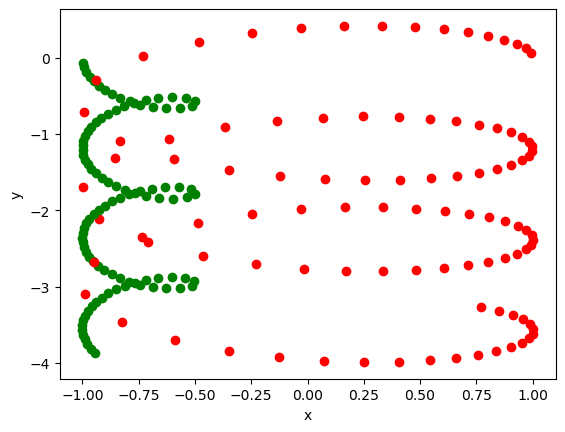

In [22]:
%matplotlib inline
# If you cannot animate, plot the trajectories
fig, ax = plt.subplots(1, 1)

for pos in positions:
    ax.scatter(pos[0,0], pos[0,1], color='green', marker='o')
    ax.scatter(pos[1,0], pos[1,1], color='red', marker='o')

plt.xlabel('x')
plt.ylabel('y');

## 3 Optimization and Profiling of Python Code

Now that we have an introduction to ODEs, lets use this a problem to practice optimizaiton on.  As discussed in lecture, Python has a builtin profiler `cProfile` which can tell us the functions in which our program spends most of its time.

Once we have identified these functions we can consider several optimatization strategies for improving code performance.

### Profiling

The first and most important step of optimization is to determine which functions your code spends most of its time in. It makes no sense to spend significant time optimization a function if the code spends a fraction of 1% of its time there, but functions that constitute the bulk of the time *may* be worth optimization.

The Python builtin profiler is the best tool for this job.  In a Jupyter notebook, we can use the magic commands %prun or %%prun. Lets test this out using our N-body integrator, now with a larger number of masses.

In [23]:
import numpy as np 

N_massive = 20
N_bodies = N_massive
M = np.ones(N_bodies)

def Nbody_derivatives(pos, vel):
    dpdt = vel
    dvdt = np.zeros(vel.shape)
    for i in range(N_bodies):
        for j in range(N_bodies):
            if i == j: 
                continue
            r = np.linalg.norm(pos[j]-pos[i])
            mass = M[j]
            rhat = (pos[j] - pos[i])/r
            dvdt[i] -= mass/(r*r)*rhat
        
    return dpdt, dvdt

def initial_conditions() : 
    pos = np.random.random([N_bodies,3])
    vel = np.random.random([N_bodies,3])

    return pos, vel

def run_Nbody_rk2(tend, tframe, dt, p0, v0, derivatives):
    p, v = p0.copy(), v0.copy()
    t = 0
    tnext = tframe
    positions = [p.copy()]
    while t<tend :
        while t < tnext :
            delta_t = min(tnext-t,dt)
            dpdt, dvdt = derivatives(p,v) 
            phalf, vhalf = p+dpdt*0.5*delta_t, v+dvdt*0.5*delta_t
            dpdt, dvdt = derivatives(phalf, vhalf)
            p, v = p + dpdt*delta_t, v + dvdt*delta_t
            t += delta_t

        positions.append(p.copy())
        tnext += tframe
    return positions

In [24]:
tframe = 0.01
dt = 0.001
frames = 100

# use the same initial conditions for all future runs
p0, v0 = initial_conditions()

In [28]:
# run with profiling
%prun positions = run_Nbody_rk2(frames*tframe, tframe, dt, p0, v0, Nbody_derivatives)

         6085207 function calls in 8.541 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     2000    4.787    0.002    8.521    0.004 283640628.py:7(Nbody_derivatives)
   760000    2.109    0.000    3.588    0.000 _linalg.py:2575(norm)
   760000    0.782    0.000    0.782    0.000 {method 'dot' of 'numpy.ndarray' objects}
   760000    0.225    0.000    0.301    0.000 _linalg.py:128(isComplexType)
   760000    0.205    0.000    0.205    0.000 {method 'ravel' of 'numpy.ndarray' objects}
  1520000    0.158    0.000    0.158    0.000 {built-in method builtins.issubclass}
   760000    0.144    0.000    0.144    0.000 _linalg.py:2571(_norm_dispatcher)
   760000    0.109    0.000    0.109    0.000 {built-in method numpy.asarray}
        1    0.018    0.018    8.540    8.540 283640628.py:27(run_Nbody_rk2)
     2000    0.002    0.000    0.002    0.000 {built-in method numpy.zeros}
     1000    0.001    0.000    0.001    0.000 {buil

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate(i, positions):
    ax.clear()
    # Get the point from the points list at index i
    pos = positions[i]
    ax.scatter(pos[:,0], pos[:,1], color='green', marker='o')
    # Set the x and y axis to display a fixed range
    ax.set_xlim([-10,10])
    ax.set_ylim([-10,10])

fig, ax = plt.subplots()
ani = FuncAnimation(fig, lambda i : animate(i, positions), frames=len(positions), interval=50, repeat=False)
video = ani.to_html5_video()
html = display.HTML(video)
display.display(html)
plt.close()

I found that the total run took 8 sec with almost all of the time in `Nbody_derivatives()`. (It will vary from computer to computer.) Here, cumtime is the cumulative time spent in the function and functions called from this function. Hence, almost all of the time for the N-body problem is spent evaluating the derivatives so this is the place to improve things.

Now the questions is: how do we do that? Lets consider several options.

### Make better use of NumPy

The first thing we want to do is rewrite the code so that it is more pythonic -- mainly so that it makes better usef of Python's builtin functions.

## **Student Completion**

Give it a try yourself before looking at my answer.  Maybe you can do better than me?

In [27]:
def Nbody_derivatives2(pos, vel):
    pass

%prun positions = run_Nbody_rk2(frames*tframe, tframe, dt, p0, v0, derivatives=Nbody_derivatives2)

TypeError: cannot unpack non-iterable NoneType object

My solutions is below
<br><br><br><br><br><br><br><br><br><br><br><br>

In [29]:
# getting rid of those for loops
def Nbody_derivatives2(pos, vel):
    dpdt = vel
    dvdt = np.zeros(vel.shape)
    rvec = pos[np.newaxis,:,:] - pos[:,np.newaxis,:] 
    r = np.maximum(np.linalg.norm(rvec,axis=-1),1e-30)
    dvdt = -((M[np.newaxis,:]/(r*r*r))[:,:,np.newaxis]*rvec).sum(axis=1)
    return dpdt, dvdt

%prun positions = run_Nbody_rk2(frames*tframe, tframe, dt, p0, v0, Nbody_derivatives2)

         27207 function calls in 0.134 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     2000    0.053    0.000    0.120    0.000 2748274856.py:2(Nbody_derivatives2)
     4000    0.047    0.000    0.047    0.000 {method 'reduce' of 'numpy.ufunc' objects}
     2000    0.014    0.000    0.040    0.000 _linalg.py:2575(norm)
        1    0.013    0.013    0.133    0.133 283640628.py:27(run_Nbody_rk2)
     2000    0.001    0.000    0.026    0.000 {method 'sum' of 'numpy.ndarray' objects}
     2000    0.001    0.000    0.001    0.000 {built-in method numpy.zeros}
     2000    0.001    0.000    0.025    0.000 _methods.py:50(_sum)
     2000    0.001    0.000    0.001    0.000 {method 'conj' of 'numpy.ndarray' objects}
     2000    0.000    0.000    0.000    0.000 _linalg.py:2571(_norm_dispatcher)
     2000    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
     2000    0.000    0.000    0.000    0.000 {bui

In [ ]:
%matplotlib inline
fig, ax = plt.subplots()
ani = FuncAnimation(fig, lambda i : animate(i, positions), frames=len(positions), interval=50, repeat=False)
video = ani.to_html5_video()
html = display.HTML(video)
display.display(html)
plt.close()

This was a significant speedup -- about a factor of 100!, and all we did was make better use of NumPy.  Remember that NumPy functions are mostly written in C so if we use the builtin methods and slicing effectively, we can circumvent Python's much slower performance.

But this example also illustrates a pitfall of optimization.  It is less clear what the code is doing, while the for loops in the previous function are relatively clear that we are looping over every pair of particles.

### Compile Python code with numba

Compiling Python is becoming more popular for applications where performance matters.  A popular example is **numba**, which is a just-in-time (jit) compiler that works well with NumPy. Lets try this one, but using the original code.  

It is extremely easy to use.  You can just use the decorator `@jit` before the function to optimize.

There are two mode of operation `nopython=True` or `False`.  When `nopython=True`, it produces much faster code, but there are limitations that can force it to fall back to `False` mode.

In [30]:
from numba import jit, njit

@jit(nopython=True)
def Nbody_derivatives3(pos, vel):
    dpdt = vel
    dvdt = np.zeros_like(vel)
    for i in range(N_bodies) :
        for j in range(N_bodies):
            if i == j: 
                continue
            r = np.linalg.norm(pos[j]-pos[i])
            mass = M[j]
            rhat = (pos[j] - pos[i])/r
            dvdt[i] += -mass/(r*r)*rhat
        
    return dpdt, dvdt

%prun positions = run_Nbody_rk2(frames*tframe, tframe, dt, p0, v0, Nbody_derivatives3)
# Note that the output %prun will likely be very long in this case

         5857836 function calls (5621102 primitive calls) in 6.616 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    20665    1.120    0.000    1.808    0.000 ffi.py:210(__call__)
     2000    0.311    0.000    0.312    0.000 1898012171.py:3(Nbody_derivatives3)
   131709    0.243    0.000    0.286    0.000 targetconfig.py:111(getter)
147583/25634    0.223    0.000    0.305    0.000 ir.py:321(_rec_list_vars)
       70    0.220    0.003    0.220    0.003 {method 'read' of '_io.BufferedReader' objects}
   159832    0.158    0.000    0.376    0.000 event.py:243(notify)
   893035    0.143    0.000    0.186    0.000 {built-in method builtins.isinstance}
     5376    0.104    0.000    0.106    0.000 compiler_machinery.py:428(is_registered)
    47802    0.102    0.000    0.488    0.000 event.py:209(broadcast)
268003/267763    0.099    0.000    0.379    0.000 {built-in method builtins.getattr}
    79916    0.066    0.000    0.091 

In [ ]:
fig, ax = plt.subplots()
ani = FuncAnimation(fig, lambda i : animate(i, positions), frames=frames, interval=50, repeat=False)
video = ani.to_html5_video()
html = display.HTML(video)
display.display(html)
plt.close()

This is faster than pure Python, but often only marginally so. In this case, I find its about 50% faster. That's not too bad given that all we had to do was add an `@jit`, but not as good as getting rid of the for loops with NumPy.

## Optimization with cython

We finally get the opportunity to use Cython, which we discussed in lecture a couple of weeks back. Cython is a "C-like" superset of the Python language that "converts" Python code  to C and then compiles the code to improve runtime performance.
* This means that any python program is also a cython program.
* You can give cython directives to help do the conversion faster.  

There are a number of directives, but the most important are data directives. You define the type of the data:
* cdef int -> int in c
* cdef float or cdef double -> float or double in c
* cdef int/float/double [:] or [:,:] as arrays -> int, float, double * or **
  
This may not seem like it does much, but it allows Cython to compile things in the C and use its much faster native data types.  

We use Cython in Jupyter with magic commands.

In [31]:
# load Cython
%load_ext cython

In [32]:
%%cython -a --verbose
import numpy as np
from cpython cimport array
import array
import math 

def cython_Nbody_derivatives(pos, vel, M):
    cdef int N_bodies = M.size
    cdef int i = 0, j = 0 
    cdef double [:,:] p = pos
    cdef double [:] mass = M
    rhat = np.zeros(3)
    cdef double [:] rh = rhat
    cdef double r = 0., r2 = 0.
    dpdt = vel
    dvdt_arr = np.zeros(vel.shape)
    cdef double [:,:] dvdt = dvdt_arr
    for i in range(N_bodies):
        for j in range(N_bodies):
            if i == j: 
                continue
            r2 = 0.
            for k in range(3) : 
                r2 += p[j,k]*p[j,k] + p[i,k]*p[i,k]
            r = math.sqrt(r2)
            for k in range(3) : 
                rh[k] = (p[j,k] - p[i,k])/r
                dvdt[i,k] += -mass[j]/(r*r)*rh[k]
        
    return dpdt, dvdt_arr

# Note that this might provide a long list of compilation warnings

In [33]:
def cython_derivs(pos,vel) :
    return cython_Nbody_derivatives(pos,vel,M)
    
%prun positions = run_Nbody_rk2(frames*tframe, tframe, dt, p0, v0, cython_derivs)

         3207 function calls in 0.095 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     2000    0.083    0.000    0.083    0.000 4037453494.py:1(cython_derivs)
        1    0.011    0.011    0.095    0.095 283640628.py:27(run_Nbody_rk2)
     1000    0.000    0.000    0.000    0.000 {built-in method builtins.min}
      103    0.000    0.000    0.000    0.000 {method 'copy' of 'numpy.ndarray' objects}
        1    0.000    0.000    0.095    0.095 {built-in method builtins.exec}
        1    0.000    0.000    0.095    0.095 <string>:1(<module>)
      100    0.000    0.000    0.000    0.000 {method 'append' of 'list' objects}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}

In [ ]:
# confirm it matches earlier results
fig, ax = plt.subplots()
ani = FuncAnimation(fig, lambda i : animate(i, positions), frames=frames, interval=50, repeat=False)
video = ani.to_html5_video()
html = display.HTML(video)
display.display(html)
plt.close()

This is even slightly faster than our rewrite with NumPy.  Again, we had to significanly modify our function to be more C-like so this is not gained for free, but if performance really matters, than taking a little time to speed up the code by a factor of 100 may be worth the time it takes to do the coding.

## 3. Parallelization Introduction

Parallelization is the process of running your code on multiple CPUs or CPU cores simultaneously to speed up the calculation.  We will discuss parallelization generally in next week's lecture, but the focus will be on OpenMP and MPI, mainly with applications to C/C++ and Fortran.  That said, there are a number of options for parallelizing Python code.

There are many ways of doing parallelization in Python. One way we will discuss later in the class is using apache spark. This allows parallel processing of large distributed data sets, which is used widely in the tech industry for big data. Other frameworks like dask and ray are also becoming popular.

Here we will focus on a simple way to do this using Python's `multiproccess` module. This method only works on one node, but with nodes on many machines now containing $\gtrsim 100$ CPU cores, this is sufficient for many applicaionts.

In [34]:
# Python built-in is multiprocessing, but doesn't play well with
# Jupyter so using multiprocess instead -- you probably need to
# pip/conda install it
import multiprocess  

count = 4
pool = multiprocess.Pool(processes=count)

def Nbody_derivatives3(pos, vel):
    dpdt = vel
    dvdt = np.zeros_like(vel)
    for i in range(N_bodies) :
        for j in range(N_bodies):
            if i == j: 
                continue
            r = np.linalg.norm(pos[j]-pos[i])
            mass = M[j]
            rhat = (pos[i] - pos[j])/r
            dvdt[i] += -mass/(r*r)*rhat
        
    return dpdt, dvdt

def onebody_derivatives(i, pos, vel):
    dvdt = np.zeros(3)
    for j in range(N_bodies) :
        if i == j : 
            continue
        r = np.linalg.norm( pos[j]-pos[i])
        mass = M[j]
        rhat = (pos[j] - pos[i])/r
        dvdt += -mass/(r*r)*rhat
        
    return dvdt

def parallel_Nbody_derivatives(pos, vel):
    dpdt = vel
    res = pool.starmap(onebody_derivatives, zip(range(N_bodies), [pos] * N_bodies, [vel]*N_bodies))
    dvdt = np.array(res)
    return dpdt, dvdt

%prun positionsp = run_Nbody_rk2(frames*tframe, tframe, dt, p0, v0, parallel_Nbody_derivatives)


         77207 function calls in 10.733 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     8000   10.499    0.001   10.499    0.001 {method 'acquire' of '_thread.lock' objects}
        1    0.037    0.037   10.733   10.733 283640628.py:27(run_Nbody_rk2)
     2000    0.033    0.000    0.088    0.000 pool.py:471(_map_async)
     2000    0.031    0.000    0.031    0.000 {built-in method numpy.array}
     2000    0.017    0.000   10.694    0.005 1638195434.py:35(parallel_Nbody_derivatives)
     2000    0.016    0.000    0.016    0.000 threading.py:243(__init__)
     2000    0.015    0.000   10.523    0.005 threading.py:295(wait)
     2000    0.012    0.000    0.012    0.000 {method 'put' of '_queue.SimpleQueue' objects}
     2000    0.010    0.000   10.538    0.005 threading.py:611(wait)
     2000    0.009    0.000    0.031    0.000 pool.py:747(__init__)
     2000    0.009    0.000   10.646    0.005 pool.py:369(starmap)
     

In [ ]:
fig, ax = plt.subplots()
ani = FuncAnimation(fig, lambda i : animate(i, positionsp), frames=frames, interval=50, repeat=False)
video = ani.to_html5_video()
html = display.HTML(video)
display.display(html)
plt.close()

The code actually runs slower for me! This is a common problem with parallelization -- particularly in a shared memory environment. The profiler output indicates why: almost all of the time is spent in a method `aquire` of a `_thread.lock` object. In other words it has to lock down memory to make sure that processes don't inferfere with each other. Parallelization needs to beat this overhead by doing lots of work, but the amount of work in this case is too small.

Parallelization is good if there is no contention *and* the amount of work per core is large.    But generally for most of the problems you deal with in Python, this is not the case. This is why single process optimization is the best place to start when trying to speed up code.

## **In-class Completion**

The following exercises will be done in class during the Thursday lab, but you are encouraged to read the following discusion before arriving to class.

For a simple application, lets consider the circular motion caused by gravity in the limit that the central mass is much bigger than the oribiting mass.  In this case we can reduce it to a system of first order ODEs given by
$$
\frac{d \mathbf{r}}{dt} = \mathbf{v}
$$
and
$$
\frac{d \mathbf{v}}{dt} = -\frac{G M \mathbf{r}}{r^3}
$$
Since circular motion is confined to a plane, we can write the vectors as 2D e.g. $\mathbf{r} = (x, y)$ and $\mathbf{v} = (v_x, v_y)$.

Start by writing your own function for the derivatives. For simplicity, choose units so that $G M = 4 \pi^2$. Given that Keplers Law is
$$
4\pi^2 a^3 = G M P^2
$$
this reduces to $a^3 = P^2$.

Lets try running this problem, I have already provided you a function for the derivatives.  Note that I have assumed a single vector of independent variables of the form $\mathbf{y} = (x,y,v_x,v_y)$. I have also copied two of the integrators above and written a function to run the integration.

In [42]:
def derivatives_2d(t, y, GM=None):

    # y[0:2] -> (x,y)
    # y[2:4] -> (vx, vy)
    if GM == None:
        GM = 4*np.pi**2

    dydt = np.empty_like(y)

    dydt[0:2] = y[2:4]
    r = np.sqrt(np.sum(y[0:2]**2))
    dydt[2:4] = -GM * y[0:2] / r**3
    return  dydt

def euler(derivatives, t, dt, y):
    return y + derivatives(t, y) * dt
    
def rk2(derivatives, t, dt, y):
    k1 = derivatives(t, y)
    k2 = derivatives(t, y+k1*0.5*dt)
    return y+dt*k2

def run_integrate(tend, dt, p0, v0, derivatives, integrator, tstart=0.):
    t = tstart
    y = np.empty(4)
    y[0:2] = p0
    y[2:4] = v0
    vars = [y.copy()]
    tarr = [t]
    while t<tend :
        delta_t = min(tend-t,dt)
        y = integrator(derivatives, t, delta_t, y)
        t += delta_t
        tarr.append(t)
        vars.append(y.copy())
    
    return np.array(vars), np.array(tarr)

Lets define initial conditions for a circular orbint. If we choose $GM = 4\pi^2$, we get $P=1$ for $a=1$.

In [43]:
# define initial conditions so that the semi-major axis
# is a = 1, and the velocity is correct for cicular orbit
GM = 4.*np.pi**2
pos0 = np.array([0, 1])
vel0 = np.array([-np.sqrt(GM/pos0[1]), 0.])
dt = 0.1
tend = 1. # one orbit

Ok, lets see how this goes.  Lets try Euler's method first.

Text(0, 0.5, 'y')

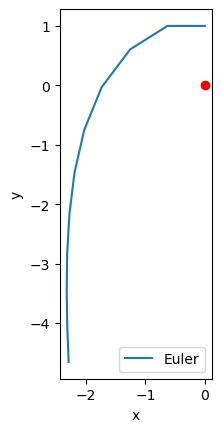

In [44]:
# run the integrator and plot the results
vars_eul, t_eul = run_integrate(tend, dt, pos0, vel0, derivatives_2d, euler)

fig = plt.figure()
ax = fig.add_subplot(111) # to set aspect ratio

# put a point at the origin
ax.scatter([0], [0], marker='o', color="r")

# draw the orbit
ax.plot(vars_eul[:,0], vars_eul[:,1], label='Euler')

ax.set_aspect("equal")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")

This is pretty terrible. We wanted something like a circle!  Even worse than what one might have expected based on our integration of the sin function above.

Text(0, 0.5, 'y')

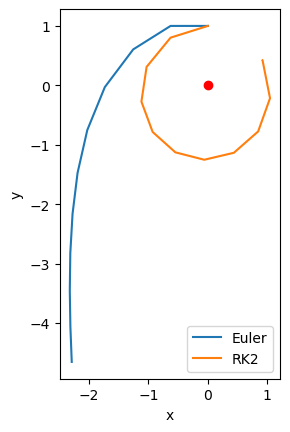

In [45]:
# run the integrator and plot the results
vars_rk2, t_rk2 = run_integrate(tend, dt, pos0, vel0, derivatives_2d, rk2)

fig = plt.figure()
ax = fig.add_subplot(111) # to set aspect ratio

# put a point at the origin
ax.scatter([0], [0], marker='o', color="r")

# draw the orbit
ax.plot(vars_eul[:,0], vars_eul[:,1], label='Euler')
ax.plot(vars_rk2[:,0], vars_rk2[:,1], label='RK2')

ax.set_aspect("equal")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")

Ok. That is much better but still not awesome. Of course, we could improve things by lowering our dt and we would get covergence to the answer.  But, lets try the power of going to and even higher order method.

**Write your own RK4 integrator and compare!**

In [ ]:
# You can generallize the example above for RK2
def rk4(derivatives, t, dt, y):
    pass

In [46]:
#MY SOLUTION -- REMOVE
# You can generallize the example above for RK2
def rk4(derivatives, t, dt, y):
    k1 = derivatives(t, y)
    k2 = derivatives(t+0.5*dt, y+k1*0.5*dt)
    k3 = derivatives(t+0.5*dt, y+k2*0.5*dt)
    k4 = derivatives(t+dt, y+k3*dt)

    return y+dt*(k1+2*(k2+k3)+k4)/6

Text(0, 0.5, 'y')

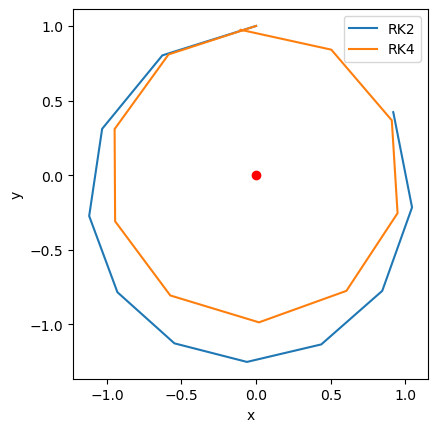

In [47]:
# run the integrator with rk4
vars_rk4, t_rk4 = run_integrate(tend, dt, pos0, vel0, derivatives_2d, rk4)

fig = plt.figure()
ax = fig.add_subplot(111) # to set aspect ratio

# put a point at the origin
ax.scatter([0], [0], marker='o', color="r")

# draw the orbit
ax.plot(vars_rk2[:,0], vars_rk2[:,1], label='RK2')
ax.plot(vars_rk4[:,0], vars_rk4[:,1], label='RK4')

ax.set_aspect("equal")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")

Now we have something approximating a circle and we can do much better by reducing the time step:

Text(0, 0.5, 'y')

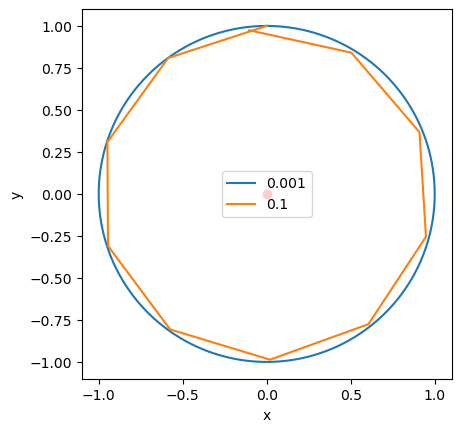

In [48]:
%matplotlib inline
# run the integrator with rk4
dt = 0.001
vars_smdt, t_smdt = run_integrate(tend, dt, pos0, vel0, derivatives_2d, rk4)

fig = plt.figure()
ax = fig.add_subplot(111) # to set aspect ratio

# put a point at the origin
ax.scatter([0], [0], marker='o', color="r")

# draw the orbit
ax.plot(vars_smdt[:,0], vars_smdt[:,1], label='0.001')
ax.plot(vars_rk4[:,0], vars_rk4[:,1], label='0.1')

ax.set_aspect("equal")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")

Looking like the answer is a good metric for assessing integrators when you know what the answer should be. But, you don't always have that luxury so it is good to check other diagnostics, such as consrerved quantities or other anticipated constants of the integration. For orbits, it is interesting to check the total orbital (gravitational plus kinetic) energy:
$$
E_{\rm tot} = \frac{1}{2} |{\bf v}|^2 - \frac{GM}{r}.
$$

**Write your own function to evaluate the total energy and see how it evolves**

Take a vector (ndarray) $\mathbf{y} = (x,y,v_x,v_y)$ as the argument and return the energy.

In [49]:
def energy(y, GM=None):
    if (GM == None):
        GM = 4.*np.pi**2
    return 0.5*(y[2]**2 + y[3]**2) - GM/np.sqrt(y[0]**2 + y[1]**2)

In [50]:
# loop over time and compute energy
def compute_energy(vars, t):

    etot = np.empty_like(t)
    for i,y in enumerate(vars):
        etot[i] = energy(y)
    return t, etot


Lets see what happens for a longer integration over 10 orbits

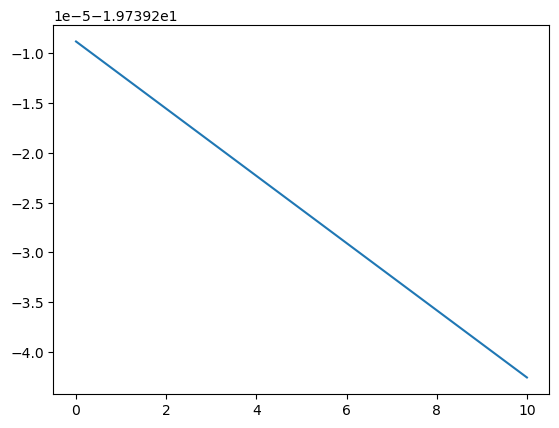

E_final - E_initial:  -3.3764396992097545e-05


In [51]:
dt = 0.01
tend = 10
vars_rk4, t_rk4 = run_integrate(tend, dt, pos0, vel0, derivatives_2d, rk4)

t, etot = compute_energy(vars_rk4, t_rk4)

plt.plot(t,etot)
plt.show()
print("E_final - E_initial: ",(etot[-1]-etot[0]))

This looks ok if not great. Energy is conserved to about one part in a million over 10 orbits with a stepsize 1/100 of an orbit.  But the fact that the energy is becoming more negative implies that it is becoming more bound and the orbit is slowly shrinking with time.

Next, try an elliptical orbit with $x=0$, $y = (1 - e)$, $v_y=0$ and
$$
v_x = -\sqrt{\frac{GM}{a} \frac{1+e}{1-e}}
$$

Use your RK4 integrator

In [52]:
# define initial conditions so that the semi-major axis
# is a = 1 and e=0.5
GM = 4.*np.pi**2
a = 1.0
e = 0.6
pos0 = np.array([0, a*(1-e)])
vel0 = np.array([-np.sqrt(GM/a*(1+e)/(1-e)), 0.])
dt = 0.1
tend = 1. # one orbit

Text(0, 0.5, 'y')

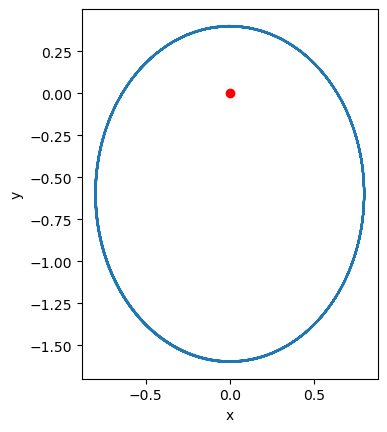

In [53]:
# run the integrator with rk4
dt = 0.01
tend = 10.
vars_e, t_e = run_integrate(tend, dt, pos0, vel0, derivatives_2d, rk4)

fig = plt.figure()
ax = fig.add_subplot(111) # to set aspect ratio

# put a point at the origin
ax.scatter([0], [0], marker='o', color="r")

# draw the orbit
ax.plot(vars_e[:,0], vars_e[:,1])

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")

Looks like an elliptical orbit.  Now check the energy.

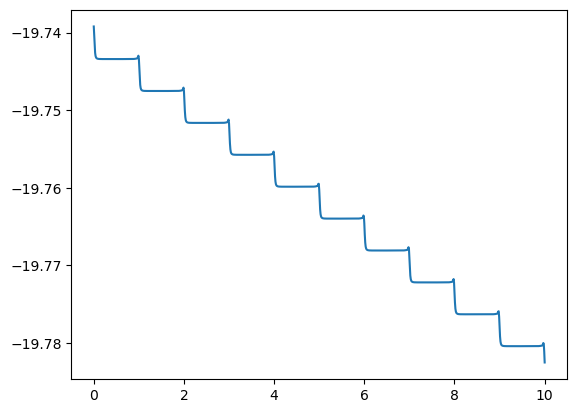

E_final - E_initial:  -0.04333469796873146


In [54]:
t, etot = compute_energy(vars_e, t_e)
plt.plot(t,etot)
plt.show()
print("E_final - E_initial: ",(etot[-1]-etot[0]))

This is not nearly as good as the circular case. We see that energy conservation is particularly poor when the orbit is close to the origin (the star).  This would almost certainly be a problem if you wanted to do a longer term integration of the sysetm.

This means that despite its relative accuracy, an integrator like RK4 is not the first choice when we want to integrate orbits for long times.  We will return to this next week.